In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = 'gpt-5-nano')

In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}


def delete_olde_messages(state: MessagesState):
    msgs = state["messages"]

    #if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id = m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_olde_messages)

In [7]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup") # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [8]:
graph = builder.compile(checkpointer=InMemorySaver())

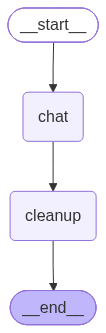

In [9]:
graph

In [10]:
config =  {"configurable": {"thread_id": "t1"}}

In [11]:
# Run multiple turns
graph.invoke({"messages": [{"role":"user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role":"user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role":"user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role":"user", "content": "what is langchain"}]}, config)
graph.invoke({"messages": [{"role":"user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role":"user", "content": "what is Gen AI"}]}, config)
graph.invoke({"messages": [{"role":"user", "content": "what is my name"}]}, config)

{'messages': [HumanMessage(content='what is langchain', additional_kwargs={}, response_metadata={}, id='c08f1392-b3eb-4d41-8074-f4ab42bf0340'),
  AIMessage(content='LangChain is an open-source framework for building applications with large language models (LLMs). It helps you “chain” together prompts, memory, data sources, and external tools to create interactive AI apps such as chatbots, question-answering systems over documents, or agents that perform actions.\n\nKey concepts and components\n- LLMs and providers: OpenAI, Cohere, local models, etc.\n- Prompts and templates: reusable prompts with variables.\n- Chains: sequences of steps that involve one or more LLM calls (e.g., LLMChain, SequentialChain).\n- Agents and tools: agents decide what action to take and can call external tools (web search, APIs, code execution, etc.). Tools are the capabilities the agent can use.\n- Memory: store and recall conversation history or state (e.g., ConversationBufferMemory).\n- Data and retrieval:

In [12]:
snap = graph.get_state(config)
print("Sorted messages after cleanup: ", len(snap.values["messages"]))

Sorted messages after cleanup:  8
